### Vamos a convertir algunas columnas a otro tipo de dato más correcto (y eliminamos las dos columnas de machine learning)

In [ ]:
#%pip install matplotlib scipy seaborn
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns

pd.set_option('display.max_columns', None)

df_clean = pd.read_csv('../data/raw/BankChurners.csv')
df_clean = df_clean.iloc[:, :-2]

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 1. Attrition_Flag -> binario
df_clean['Attrition_Flag'] = df_clean['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

# 2. Gender -> binario
df_clean['Gender'] = df_clean['Gender'].map({
    'M': 0,
    'F': 1
})

# 3. Education_Level -> categórica ordenable
orden_educacion = ['Unknown', 'Uneducated', 'High School', 'College',
                    'Graduate', 'Post-Graduate', 'Doctorate']

df_clean['Education_Level'] = pd.Categorical(
    df_clean['Education_Level'],
    categories=orden_educacion,
    ordered=True
)

# 4. Income_Category -> categórica ordenable
orden_ingresos = ['Unknown', 'Less than $40K', '$40K - $60K',
                   '$60K - $80K', '$80K - $120K', '$120K +']


df_clean['Income_Category'] = pd.Categorical(
    df_clean['Income_Category'],
    categories=orden_ingresos,
    ordered=True
)

# 5. Card_Category -> categórica ordenable (jerarquía de tarjetas)
orden_tarjeta = ['Blue', 'Silver', 'Gold', 'Platinum']

df_clean['Card_Category'] = pd.Categorical(
    df_clean['Card_Category'],
    categories=orden_tarjeta,
    ordered=True
)

# 6. Marital_Status -> categórica NO ordenable
df_clean['Marital_Status'] = pd.Categorical(
    df_clean['Marital_Status'],
    ordered=False
)

In [3]:
df_clean[['Attrition_Flag', 'Gender', 'Education_Level', 'Income_Category',
    'Card_Category', 'Marital_Status']].dtypes

Attrition_Flag        int64
Gender                int64
Education_Level    category
Income_Category    category
Card_Category      category
Marital_Status     category
dtype: object

### Comprobamos la asimetría de cada variable númerica para decidir el método de detección de outliers (sin tener en cuenta CLIENTNUM, Attrition_Flag ni Gender)

In [4]:
df_clean.select_dtypes(include=['int64', 'float64']).skew().sort_values(ascending=False)

Total_Ct_Chng_Q4_Q1         2.064031
Total_Trans_Amt             2.041003
Attrition_Flag              1.848449
Total_Amt_Chng_Q4_Q1        1.732063
Credit_Limit                1.666726
Avg_Open_To_Buy             1.661697
CLIENTNUM                   0.995601
Avg_Utilization_Ratio       0.718008
Months_Inactive_12_mon      0.633061
Total_Trans_Ct              0.153673
Contacts_Count_12_mon       0.011006
Dependent_count            -0.020826
Customer_Age               -0.033605
Months_on_book             -0.106565
Gender                     -0.116537
Total_Revolving_Bal        -0.148837
Total_Relationship_Count   -0.162452
dtype: float64

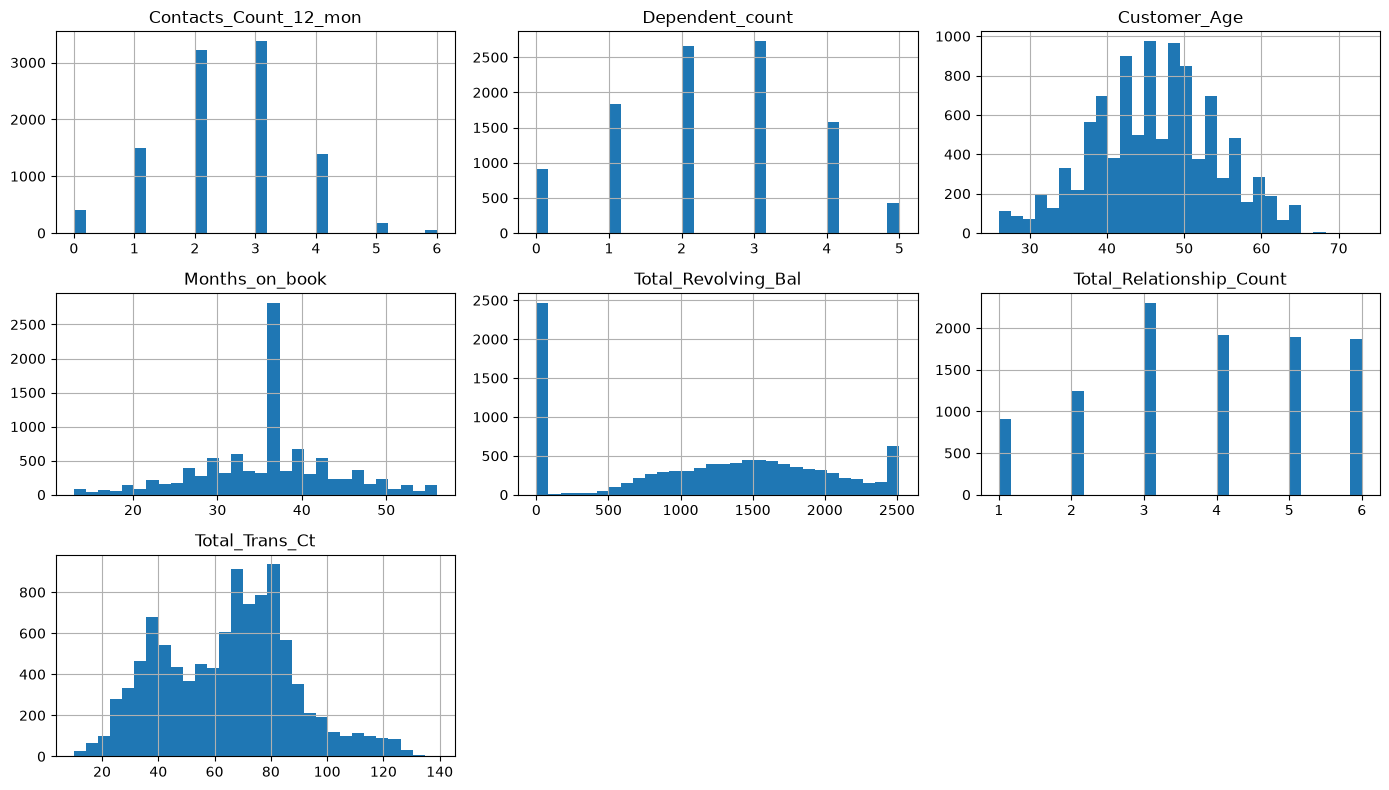

In [5]:
candidatas = ['Contacts_Count_12_mon', 'Dependent_count', 'Customer_Age',
              'Months_on_book', 'Total_Revolving_Bal',
              'Total_Relationship_Count', 'Total_Trans_Ct']

df_clean[candidatas].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()

### De las 7 variables, solo Customer_Age justifica Z-score (unimodal, simétrica, sin picos secundarios). El resto debería tratarse con IQR, y Months_on_book y Total_Revolving_Bal merecen además una revisión adicional antes de hablar de "outliers" propiamente dichos (uno por posible relleno sintético de datos desconocidos, otro por ser un segmento de cliente legítimo).

### Vamos a comprobar la magnitud del pico para Months_on_book

In [6]:
df_clean['Months_on_book'].value_counts().head(5)

Months_on_book
36    2463
37     358
34     353
38     347
39     341
Name: count, dtype: int64

In [7]:
(df_clean['Months_on_book'] == 36).mean() * 100

np.float64(24.32112175372766)

### En principio el porcentaje es desproporcionado con respecto a los valores vecinos (35, 37)

### Vamos a comparar el pefil de esos clientes contra el resto

In [8]:
df_clean.groupby(df_clean['Months_on_book'] == 36)[['Customer_Age', 'Total_Relationship_Count', 'Attrition_Flag']].mean()

,Customer_Age,Total_Relationship_Count,Attrition_Flag
Months_on_book,,,
False,46.380611,3.822286,0.156185
True,46.155907,3.782379,0.174584


### Ya que la media sola no es suficiente (dos grupos pueden tener la misma media y aun así uno tener mucha más dispersión que el otro), vamos a comparar también la desviación estándar:

In [10]:
df_clean.groupby(df_clean['Months_on_book'] == 36)['Customer_Age'].std()

Months_on_book
False    8.143922
True     7.606811
Name: Customer_Age, dtype: float64

### Debido a que el grupo de 36 meses tiene una tasa de 'churn' algo mayor para Attrition_flag (17.46% vs 15.62%), una diferencia de más o menos 1.8 puntos porcentuales, (es una diferencia pequeña pero no despreciable) vamos a ver si es estadísticamente significativa:

In [13]:
tabla = pd.crosstab(df_clean['Months_on_book'] == 36, df_clean['Attrition_Flag'])
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p:.4f}")

p-valor: 0.0330


### Y visualicemos también la dispersión real

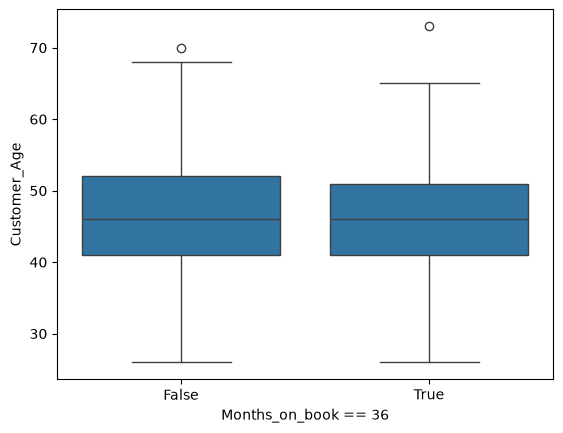

In [16]:
sns.boxplot(x=(df_clean['Months_on_book'] == 36), y=df_clean['Customer_Age'])
plt.xlabel('Months_on_book == 36')
plt.show()

### La hipótesis inicial (que 36 fuera un valor de relleno tipo "dato desconocido"para Months_on_book) queda descartada. El perfil demográfico (edad) es indistinguible entre ambos grupos, lo cual no es compatible con un placeholder que normalmente afectaría a un segmento concreto de clientes (nuevos, migrados, con datos incompletos).